In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df=pd.read_csv("/content/weight-height.csv")

In [ ]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [ ]:
df.shape

(10000, 3)

In [ ]:
df.dtypes

,0
Gender,object
Height,float64
Weight,float64


In [ ]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


#Feature Selecion

In [ ]:
df.drop("Gender",axis = 1)

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [ ]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
df.drop("Gender",axis =1,inplace=True)

#NaNs

In [ ]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [ ]:
df.isna()

,Height,Weight
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,False,False


In [ ]:
df.isna().sum()

,0
Height,0
Weight,0


#Error Detection

In [ ]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


<Axes: >

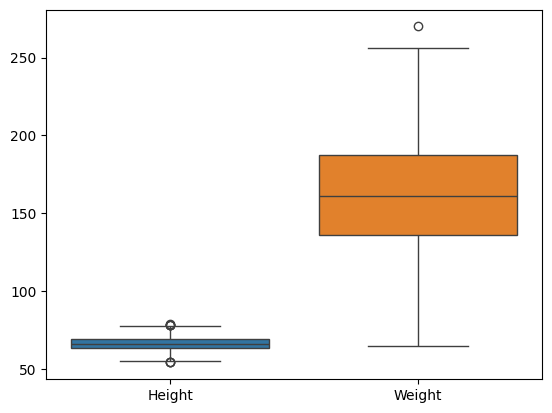

In [ ]:
sns.boxplot(df)

In [ ]:
df["Height"]

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


<Axes: ylabel='Height'>

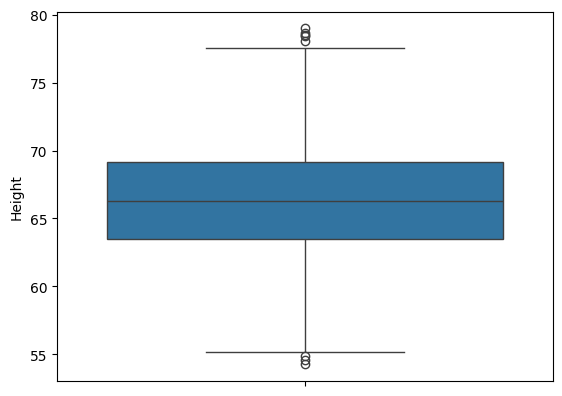

In [ ]:
sns.boxplot(df["Height"])

<Axes: ylabel='Weight'>

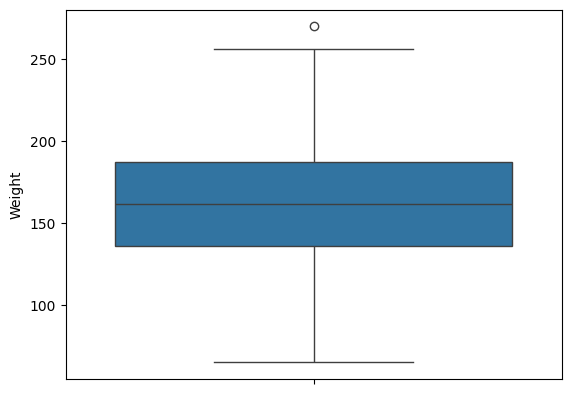

In [ ]:
sns.boxplot(df["Weight"])

#Identify Errors in Height Column

In [ ]:
df["Height"]

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
q1 = df["Height"].quantile(0.25)
q1

np.float64(63.505620481218955)

In [ ]:
q3 = df["Height"].quantile(0.75)
q3

np.float64(69.1742617268347)

In [ ]:
df["Height"].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [ ]:
iqr = q3 - q1
iqr

np.float64(5.668641245615746)

In [ ]:
lowerlimit = q1 - 1.5*iqr
lowerlimit

np.float64(55.00265861279534)

In [ ]:
upperlimit = q3 + 1.5*iqr
upperlimit

np.float64(77.67722359525831)

In [ ]:
df["Height"]< lowerlimit

,Height
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df[df["Height"] < lowerlimit]

,Height,Weight
6624,54.616858,71.393749
7294,54.873728,78.606670
9285,54.263133,64.700127


In [ ]:
df["Height"] > upperlimit

,Height
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df[df["Height"] > upperlimit]

,Height,Weight
994,78.095867,255.690835
1317,78.462053,227.342565
2014,78.998742,269.989699
3285,78.528210,253.889004
3757,78.621374,245.733783


In [ ]:
(df["Height"] < lowerlimit) | (df["Height"] > upperlimit)

,Height
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df[ (df["Height"] < lowerlimit) | (df["Height"] > upperlimit) ]

,Height,Weight
994,78.095867,255.690835
1317,78.462053,227.342565
2014,78.998742,269.989699
3285,78.528210,253.889004
3757,78.621374,245.733783
6624,54.616858,71.393749
7294,54.873728,78.606670
9285,54.263133,64.700127


#Capping

In [ ]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [ ]:
df["Height"]

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
df["Height"].map(lambda x: lowerlimit if x < lowerlimit else upperlimit if x > upperlimit else x)

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
df["Height"]=df["Height"].map(lambda x: lowerlimit if x < lowerlimit else upperlimit if x > upperlimit else x)

In [ ]:
df[(df["Height"] < lowerlimit) | (df["Height"] > upperlimit)]

,Height,Weight


In [ ]:
df.shape

(10000, 2)

<Axes: ylabel='Height'>

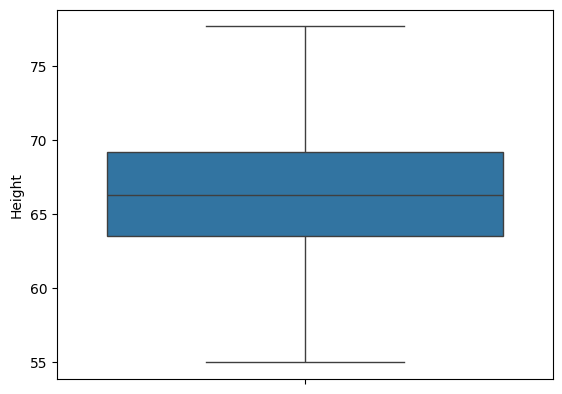

In [ ]:
sns.boxplot(df["Height"])

#Weight Columns

In [ ]:
df["Weight"]

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801
...,...
9995,136.777454
9996,170.867906
9997,128.475319
9998,163.852461


<Axes: ylabel='Weight'>

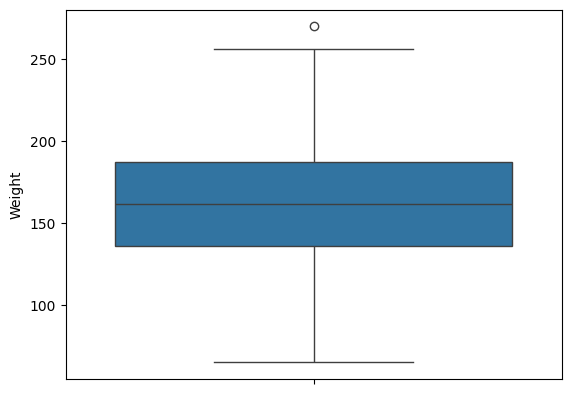

In [ ]:
sns.boxplot(df["Weight"])

In [ ]:
qw1 = df["Weight"].quantile(0.25)
qw1


np.float64(135.8180513055015)

In [ ]:
qw3 = df["Weight"].quantile(0.75)
qw3

np.float64(187.16952486868348)

In [ ]:
df["Weight"].describe()

,Weight
count,10000.000000
mean,161.440357
std,32.108439
min,64.700127
25%,135.818051
50%,161.212928
75%,187.169525
max,269.989699


In [ ]:
iqr = qw3 - qw1
iqr

np.float64(51.35147356318197)

In [ ]:
lower = qw1 -(1.5 * iqr)
upper = qw3 +(1.5 * iqr)

In [ ]:
lower
upper

np.float64(264.19673521345646)

In [ ]:
df[df["Weight"] < lower]

,Height,Weight


In [ ]:
df[df["Weight"] > upper]

,Height,Weight
2014,77.677224,269.989699


In [ ]:
(df["Weight"] < lower) | (df["Weight"] > upper)

,Weight
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df[(df["Weight"] < lower) | (df["Weight"] > upper)]

,Height,Weight
2014,77.677224,269.989699


In [ ]:
df.drop(2014)

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [ ]:
df.drop(2014,inplace = True)

<Axes: ylabel='Weight'>

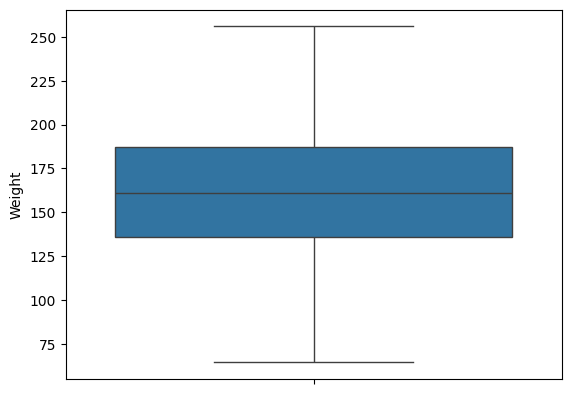

In [ ]:
sns.boxplot(df["Weight"])

#Encoding

In [ ]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [ ]:
df.dtypes

,0
Height,float64
Weight,float64


#Data Seperation

In [ ]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [ ]:
df["Height"]

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
df[["Height"]]

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
x = df[["Height"]]
x

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [ ]:
y = df["Weight"]
y

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801
...,...
9995,136.777454
9996,170.867906
9997,128.475319
9998,163.852461


#Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20,random_state=22)

In [ ]:
x_train.shape

(7999, 1)

In [ ]:
x_test.shape

(2000, 1)

In [ ]:
x.shape

(9999, 1)

In [ ]:
y_train.shape

(7999,)

In [ ]:
y_test.shape

(2000,)

In [ ]:
y.shape

(9999,)

In [ ]:
x.head(7)

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
5,67.253016
6,68.785081


In [ ]:
x_train.head()

,Height
5380,59.239199
655,65.224692
2950,68.690373
3114,71.954680
3883,65.346768


In [ ]:
x_test.head()

,Height
961,70.046931
2212,69.123058
6942,63.422933
4448,72.717613
9760,56.534166


#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model

LinearRegression()

In [ ]:
lr_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr_model.score(x_test, y_test)

0.8537121581690107

#Auto Random State

In [ ]:
for i in range(500):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
sc_list = []
for i in range(500):
    xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.20, random_state=i)
    linreg = LinearRegression()
    linreg.fit(xtrain, ytrain)
    sc = linreg.score(xtest, ytest)
    # print("Random State : ", i)
    # print("Score :",sc)
    sc_list.append(sc)
m = max(sc_list)
print(m)
id = sc_list.index(m)
print(id)

0.870529204718899
187


In [ ]:
lr_model

LinearRegression()

In [ ]:
lr_model.coef_

array([7.70245889])

In [ ]:
lr_model.intercept_

np.float64(-349.7353972031398)

In [ ]:
linreg1 = LinearRegression()

In [ ]:
lr_model

LinearRegression()

In [ ]:
linreg1

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error,mean_squared_error

In [ ]:
lr_model.predict(x_test)

array([189.79820733, 182.68211411, 138.77713843, ..., 195.95933207,
       156.10664497, 112.80771896])

In [ ]:
y_pred = lr_model.predict(x_test)
y_pred

array([189.79820733, 182.68211411, 138.77713843, ..., 195.95933207,
       156.10664497, 112.80771896])

In [ ]:
y_test

,Weight
961,183.619621
2212,179.024645
6942,124.689047
4448,210.365362
9760,97.743896
...,...
6570,142.775819
4493,154.503178
2464,196.306310
8784,129.103220


In [ ]:
r2_score(y_test,y_pred)

0.8537121581690107

In [ ]:
mean_squared_error(y_test,y_pred)

151.50056195599603

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(12.308556452971894)

In [ ]:
100 - np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(87.6914435470281)